<details>
  <summary><strong>MIT License (クリックで展開)</strong></summary>

  <pre>
MIT License
Copyright (c) 2023-2024 AI Course Notebook Contributors
Repository: https://github.com/arch-inform-kaken-group/ai-course-notebooks

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.
  </pre>
</details>


# はじめに

簡単なニューラルネットワークのデモサイト：
https://playground.tensorflow.org/

# mnist （手書き文字）の教師あり分類
今回のハンズオンは，深層学習（ディープラーニング）のモデルを作成する流れのイメージを体感していただくことが目標です．<br>
深層学習について，詳しくは教科書3章で学習します．<br>

## 目的：「0」～「9」までの手書き文字を分類すること
MNIST database（Modified National Institute of Standards and Technology database）は，「0」～「9」までの手書き数字による画像データセットであり，機械学習・深層学習分野における練習問題などで，しばしば使用されるデータセットです． これも，幾つかのPythonのライブラリではお試し用のデータとして簡単に使用できるようになっています．

MNISTテストデータセットのサンプル画像：

![mnistデータセットのサンプル画像](https://upload.wikimedia.org/wikipedia/commons/2/27/MnistExamples.png "MNISTテストデータセットのサンプル画像")

<small>MNIST database (Apr. 12, 2023, 00:15 UTC). In Wikipedia: The Free Encyclopedia. Retrieved from https://en.wikipedia.org/wiki/MNIST_database</small>




今回は，この「0」～「9」の手書き文字画像を，深層学習モデルを用いて「0」～「9」に自動で分類を行います．

使える情報（入力データの種類）：「0」～「9」の**手書き文字画像** <br>
取得したい結果（出力データの種類）：「0」～「9」の数値へ分類 <br>

このデータセットの特徴として，下記のような一通りの前処理が行われているため，手軽に実データを使用することが出来ることが挙げられます．
* 手書き文字の大きさが揃えられている．
* 手書き文字は画像の中央に配置されている．
* 学習用とテスト用にデータセットが分割されている．
    *   学習用：60000件，テスト用：10000件
* 正解ラベルが割り当てられている．


［本家（Paper）］[Y. Lecun, L. Bottou, Y. Bengio and P. Haffner, "Gradient-based learning applied to document recognition," in Proceedings of the IEEE, vol. 86, no. 11, pp. 2278-2324, Nov. 1998, doi: 10.1109/5.726791.](https://ieeexplore.ieee.org/document/726791)

［本家（Webサイト）］http://yann.lecun.com/exdb/mnist/

## GPU の利用確認とTensorFlowのバージョン確認

In [ ]:
!nvidia-smi

Thu Apr 25 00:58:20 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   42C    P8               9W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [ ]:
import tensorflow as tf
import sklearn
import os

# colab にプリインストールされていないライブラリを導入
!pip install -q japanize_matplotlib # matplotlib日本語化用の外部ライブラリ

print('TensorFlow version:',tf.__version__)
print('scikit-learn version:',sklearn.__version__)

restart_flag = False

if tf.__version__ != '2.15.0':
    !pip install -q --upgrade tensorflow==2.15.0
    print('TensorFlow version:',tf.__version__)
    restart_flag = True

if sklearn.__version__ != '1.2.2':
    !pip install -q --upgrade scikit-learn==1.2.2
    print('scikit-learn version:',sklearn.__version__)
    restart_flag = True

# 以下は，ライブラリのバージョンが変更された場合のみ実行されます．
if restart_flag :
    print("ライブラリバージョンを変更した場合に，自動でランタイムを再起動します．")
    print("colabの場合は【不明な理由でクラッシュした】旨の警告が左下に出てきますが，")
    print("これは無視しても問題ないので次以降のコードセルを実行してください．")
    # ランタイムを再起動させるために，わざとクラッシュさせています．
    get_ipython().kernel.do_shutdown(restart=True)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 10.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
TensorFlow version: 2.15.0
scikit-learn version: 1.2.2


### パッケージインポート

In [ ]:
import os # os：標準ライブラリ，OS依存の処理（環境変数やフォルダ作成など）を扱う
import datetime # datetime：標準ライブラリ，日付関連データを扱う
import random # random：標準ライブラリ，擬似乱数発生器
import numpy as np # numpy：数値計算用ライブラリの一つ

import pandas as pd # pandas：表計算用ライブラリの一つ
pd.options.display.precision = 4 #表示桁数調整用の引数

from IPython.display import display # Colabなどで一部のデータをprint()よりも綺麗に出力できる関数
import matplotlib.pylab as plt # matplotlib：グラフ描画用ライブラリの一つ

import japanize_matplotlib # matplotlib日本語化用の外部ライブラリ

import seaborn as sns # seaborn：グラフ描画用ライブラリの一つ
from sklearn.metrics import classification_report # 機械学習ライブラリの一つ（今回はPrecision,Recall,F1-Scoreの出力時に使用するのみ）
# tensorboard：深層学習ライブラリTensorFlowのダッシュボード出力用設定
%load_ext tensorboard
import tensorflow as tf # TensorFlow：深層学習ライブラリ一つ

### 擬似乱数発生器のrandom seed 固定

* 下記プログラム中で生成・使用される擬似乱数列を固定します．
* random seed は擬似乱数列を生成する時の初期化に使われる数値です．
* 明示的に指定しない場合は，時刻などで初期化されます．
* 今回は再現性を確保する（誰がいつ実行しても同じ擬似乱数列を生成させる）ために random seed を固定します．

<small> ※ colab では割り当てられるCPU/GPUやライブラリバージョンの違いにより，完全再現は難しい場合もあります.</small>

In [ ]:
def set_seed(seed=123):
    # hash seed の固定
    os.environ["PYTHONHASHSEED"] = str(seed)
    # Python外部ライブラリ：TensorFlow の ニューラルネットワークを決定論的に動作させる
    os.environ['TF_DETERMINISTIC_OPS'] = 'true'
    # Python外部ライブラリ：TensorFlow の ニューラルネットワークを決定論的に動作させる
    os.environ['TF_CUDNN_DETERMINISTIC'] = 'true'
    # Python標準ライブラリ：random の seed固定
    random.seed(seed)
    # Python外部ライブラリ：Numpy の seed固定
    np.random.seed(seed)
    # Python外部ライブラリ：TensorFlow の seed固定
    tf.random.set_seed(seed)

set_seed(42)

## tensorflow / keras

### データセットの取得と分割

In [ ]:
# 本家のWebサイトではなく，tensorflowライブラリから
# 利用できるようになっているMNISTデータセットを読み込みます．
# こちらの方がデータ形式を変換する作業などを省けるためです．

(x_learn, y_learn), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# モデルの訓練時に使用するデータを，訓練用データと検証用データへ分割する
x_train = x_learn[ 0 : int(len(x_learn)*0.7), : ]
y_train = y_learn[ 0 : int(len(y_learn)*0.7) ]

x_valid = x_learn[ int(len(x_learn)*0.7) : len(x_learn), : ]
y_valid = y_learn[ int(len(y_learn)*0.7) : len(y_learn) ]

# データセットの数を確認する

# 訓練用のデータ
print("x_train : ", x_train.shape)
print("y_train : ", y_train.shape)

# 検証用のデータ
print("x_valid : ", x_valid.shape)
print("y_valid : ", y_valid.shape)

# テスト用のデータ
print("x_test : ", x_test.shape)
print("y_test : ", y_test.shape)

11490434/11490434 [==============================] - 1s 0us/step
x_train :  (42000, 28, 28)
y_train :  (42000,)
x_valid :  (18000, 28, 28)
y_valid :  (18000,)
x_test :  (10000, 28, 28)
y_test :  (10000,)


各データセットの用途について：

　 | 用途 | 説明
--- | --- | ---
train dataset | 訓練用データセット | モデルの訓練に利用するデータ
validation datset<br>evaluation dataset | 検証用データセット<br>評価用データセット | モデルの訓練時に、モデルの精度を検証するために利用するデータ。<br>訓練時の繰り返しごとに記録し、未知のデータでの性能が向上しているか(汎化しているか)を評価する。
test dataset| テストデータセット | 出来上がったモデルに対して、どのくらいの精度が出ているかテストするために利用するデータ


機械学習/深層学習 において validation dataset と test dataset の用途は何が異なるか：<br>
* 検証用データセット / validation datasetは，人間が設定するパラメータ（ハイパーパラメータ）を調整するときの指標として使用する．
* 試験用データセット / test dataset は，ハイパーパラメータの調整と訓練が終わった後のモデルの性能を評価するためだけに使用する．

モデルの訓練やパラメータの調整には **一度も使用しない** test dataset を用意することで，未知のデータに対する性能を擬似的に評価する．
ここで，モデルの訓練やハイパーパラメータの調整に使用したdatasetを，最終的なモデルの性能評価に使用してしまうと，実運用時よりも良い結果が得られてしまう．

### データセットの中身を可視化（一部）

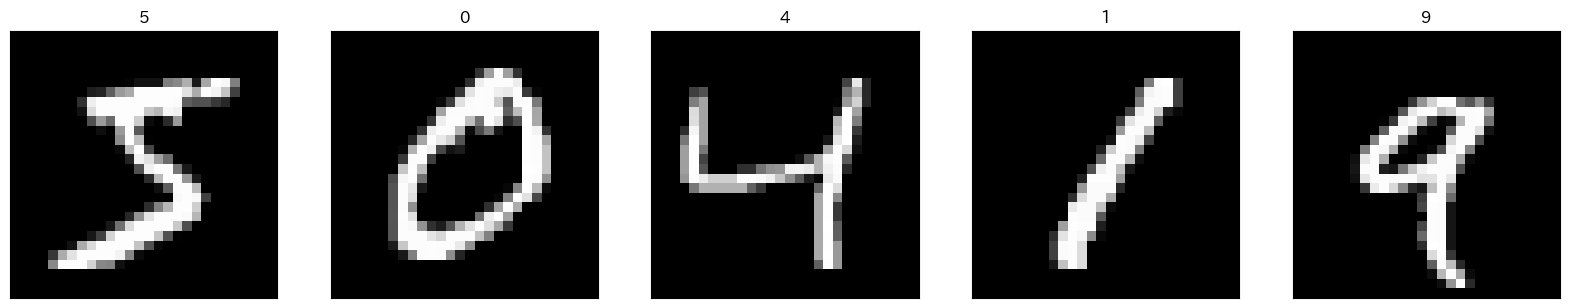

In [ ]:
# データセットの中身を5つ可視化する

fig = plt.figure(figsize=(20,20))
for i in range(5):
    ax = fig.add_subplot(1, 5, i+1, xticks=[], yticks=[])
    ax.imshow(x_train[i].reshape(28,28), cmap='gray')
    ax.set_title(str(y_train[i]))
plt.show()

### データセットの正規化（Min-Max Normalization）

このデータセットの画像は，0から255までの整数から構成されるグレイスケール画像です．

正規化（Min-Max Normalization）は，最大値および最小値が決まっている場合などに，0から1の範囲内にスケーリングする手法です．画像処理などでは学習コストを下げる目的で利用されることが多いです．

$$ X_{norm} = \frac{X−X_{min}}{X_{max}−X_{min}} $$

<small> ※ Min-Max Normalization は外れ値の影響を強く受けます．最大値および最小値が決まっていない場合，外れ値が存在する場合は，別の手法を採用することが多いです．</small>

In [ ]:
print("Min-Max Normalization 前")
print("x_train min", x_train.min())
print("x_train max", x_train.max())

x_train = ( x_train - np.min(x_train) ) / ( np.max(x_train) - np.min(x_train) )
x_valid = ( x_valid - np.min(x_valid) ) / ( np.max(x_valid) - np.min(x_valid) )
x_test  = ( x_test  -  np.min(x_test) ) / (  np.max(x_test) -  np.min(x_test) )

print("Min-Max Normalization 後")
print("x_train min", x_train.min())
print("x_train max", x_train.max())

Min-Max Normalization 前
x_train min 0
x_train max 255
Min-Max Normalization 後
x_train min 0.0
x_train max 1.0


### ラベルデータのone-hotエンコーディング


In [ ]:
# ラベルデータのone-hotエンコーディング

print("ラベルデータのone-hotエンコーディング 前")
print("y_train[0]：", y_train[0])
print("y_valid[0]：", y_valid[0])
print("y_test[0] ：", y_test[0])
print()

y_train_onehot = tf.keras.utils.to_categorical(y_train)
y_valid_onehot = tf.keras.utils.to_categorical(y_valid)
y_test_onehot = tf.keras.utils.to_categorical(y_test)

print("ラベルデータのone-hotエンコーディング 後")
print("y_train_onehot[0]：", y_train_onehot[0])
print("y_valid_onehot[0]：", y_valid_onehot[0])
print("y_test_onehot[0] ：", y_test_onehot[0])


ラベルデータのone-hotエンコーディング 前
y_train[0]： 5
y_valid[0]： 1
y_test[0] ： 7

ラベルデータのone-hotエンコーディング 後
y_train_onehot[0]： [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
y_valid_onehot[0]： [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
y_test_onehot[0] ： [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


### モデルの定義

In [ ]:
# モデルの定義

# input層（入力層）
inputs_images = tf.keras.layers.Input( shape = (28, 28, 1), name = 'input' )

# Flatten層（平坦化層）
# (None, 28, 28, 1) -> (None, 784)
x = tf.keras.layers.Flatten()(inputs_images)

# Dense層（全結合層）
# (None, 784) -> (None, 512)
x = tf.keras.layers.Dense( units = 512, activation = 'relu' , name='fc_1')(x)
# (None, 512) -> (None, 256)
x = tf.keras.layers.Dense( units = 256, activation = 'relu' , name='fc_2')(x)
# (None, 256) -> (None, 128)
x = tf.keras.layers.Dense( units = 128, activation = 'relu' , name='fc_3')(x)
# (None, 128) -> (None, 10)
outputs = tf.keras.layers.Dense( units = 10, activation = 'softmax' )(x)

model = tf.keras.Model( inputs = inputs_images, outputs = outputs, name = 'mnist_model' )

# モデルのコンパイル（最適化アルゴリズム・損失関数・評価指標などを設定）
# 損失関数は2.6章で学びます．
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# モデルの構造をテキストで出力
model.summary()

Model: "mnist_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 28, 28, 1)]       0         
                                                                 
 flatten (Flatten)           (None, 784)               0         
                                                                 
 fc_1 (Dense)                (None, 512)               401920    
                                                                 
 fc_2 (Dense)                (None, 256)               131328    
                                                                 
 fc_3 (Dense)                (None, 128)               32896     
                                                                 
 dense (Dense)               (None, 10)                1290      
                                                                 
Total params: 567434 (2.16 MB)
Trainable params: 567434

イメージとしては，以下のような構造です．
※ユニット数（○の数）は省略しています．

nn_2.svg

### 未訓練のモデルで推論させてみる

1/1 [==============================] - 1s 877ms/step


,0,1,2,3,4,5,6,7,8,9
y_test_pred (i=0),0.104,0.083,0.1029,0.0777,0.1115,0.0993,0.0846,0.0952,0.1273,0.1144



y_test_predで最も確率が高いラベル (i=0):  8
y_test_true (i=0):  7 

x_test（手書き文字画像） (i=0): 


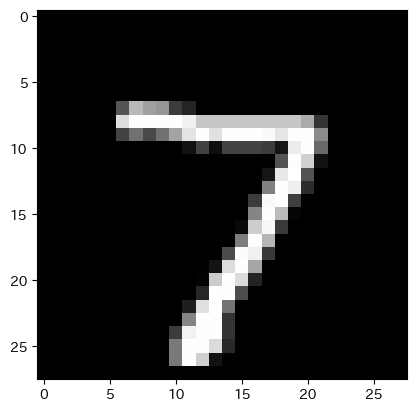

In [ ]:
# テストデータの内，先頭1件のデータを可視化
for i in [0]:
    y_true = y_test[i]
    y_pred = model.predict(x_test[i].reshape(1,28,28))[0]
    display(pd.DataFrame(columns = range(10), index = [f'y_test_pred (i={str(i)})'], data=[y_pred.tolist()]))

    print("\ny_test_predで最も確率が高いラベル", "(i="+str(i)+"): ", tf.math.argmax(y_pred).numpy())
    print("y_test_true", "(i="+str(i)+"): ", y_true, "\n")

    print("x_test（手書き文字画像）", "(i="+str(i)+"): ")
    plt.imshow(x_test[i], cmap='gray')
    plt.show()
    print()

誤推論していることが分かります．ここからモデルを訓練していきましょう．

### モデルの訓練

In [ ]:
# 訓練中のログファイルを作成する準備
callbacks = []
callbacks.append(tf.keras.callbacks.CSVLogger('training_log.csv'))

# .TensorBoardを作成する準備
os.makedirs('/contents/logs/fit/', exist_ok=True)# フォルダ作成
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

callbacks.append(tensorboard_callback)

# モデルの訓練（GPUで1分ほど）
history = model.fit(x_train, y_train_onehot,
                    batch_size = 128,
                    epochs = 20,
                    verbose = 1,
                    validation_data = (x_valid, y_valid_onehot),
                    callbacks = callbacks
                    )


model_save_path = 'trained_model_mnist'
model.save(model_save_path)

Epoch 1/20
329/329 [==============================] - 5s 8ms/step - loss: 0.2733 - accuracy: 0.9208 - val_loss: 0.1950 - val_accuracy: 0.9414
Epoch 2/20
329/329 [==============================] - 2s 5ms/step - loss: 0.0954 - accuracy: 0.9706 - val_loss: 0.1001 - val_accuracy: 0.9704
Epoch 3/20
329/329 [==============================] - 2s 5ms/step - loss: 0.0586 - accuracy: 0.9809 - val_loss: 0.1121 - val_accuracy: 0.9671
Epoch 4/20
329/329 [==============================] - 2s 5ms/step - loss: 0.0439 - accuracy: 0.9860 - val_loss: 0.1396 - val_accuracy: 0.9628
Epoch 5/20
329/329 [==============================] - 2s 5ms/step - loss: 0.0320 - accuracy: 0.9895 - val_loss: 0.1023 - val_accuracy: 0.9721
Epoch 6/20
329/329 [==============================] - 2s 5ms/step - loss: 0.0256 - accuracy: 0.9912 - val_loss: 0.1043 - val_accuracy: 0.9719
Epoch 7/20
329/329 [==============================] - 2s 6ms/step - loss: 0.0191 - accuracy: 0.9938 - val_loss: 0.1065 - val_accuracy: 0.9757
Epoch 

### モデルの評価

In [ ]:
train_loss, train_acc = model.evaluate(x_train, y_train_onehot, verbose=1)
print("loss (train): {:.4}".format(train_loss))
print("accuracy (train): {:.4}".format(train_acc))

print()

valid_loss, valid_acc = model.evaluate(x_valid, y_valid_onehot, verbose=1)
print("loss (valid): {:.4}".format(valid_loss))
print("accuracy (valid): {:.4}".format(valid_acc))

print()

test_loss, test_acc = model.evaluate(x_test, y_test_onehot, verbose=1)
print("loss (test): {:.4}".format(test_loss))
print("accuracy (test): {:.4}".format(test_acc))

1313/1313 [==============================] - 3s 2ms/step - loss: 0.0027 - accuracy: 0.9990
loss (train): 0.002695
accuracy (train): 0.999

563/563 [==============================] - 1s 2ms/step - loss: 0.1248 - accuracy: 0.9775
loss (valid): 0.1248
accuracy (valid): 0.9775

313/313 [==============================] - 1s 2ms/step - loss: 0.0925 - accuracy: 0.9809
loss (test): 0.0925
accuracy (test): 0.9809


#### ログの表示

In [ ]:
log_df = pd.read_csv('training_log.csv')
display(log_df.head(20))

,epoch,accuracy,loss,val_accuracy,val_loss
0,0,0.9208,0.2733,0.9414,0.1950
1,1,0.9706,0.0954,0.9704,0.1001
2,2,0.9809,0.0586,0.9671,0.1121
3,3,0.9860,0.0439,0.9628,0.1396
4,4,0.9895,0.0320,0.9721,0.1023
5,5,0.9912,0.0256,0.9719,0.1043
6,6,0.9938,0.0191,0.9757,0.1065
7,7,0.9938,0.0192,0.9734,0.1151
8,8,0.9931,0.0201,0.9712,0.1274
9,9,0.9944,0.0177,0.9774,0.0996


#### 損失関数と評価指標の推移

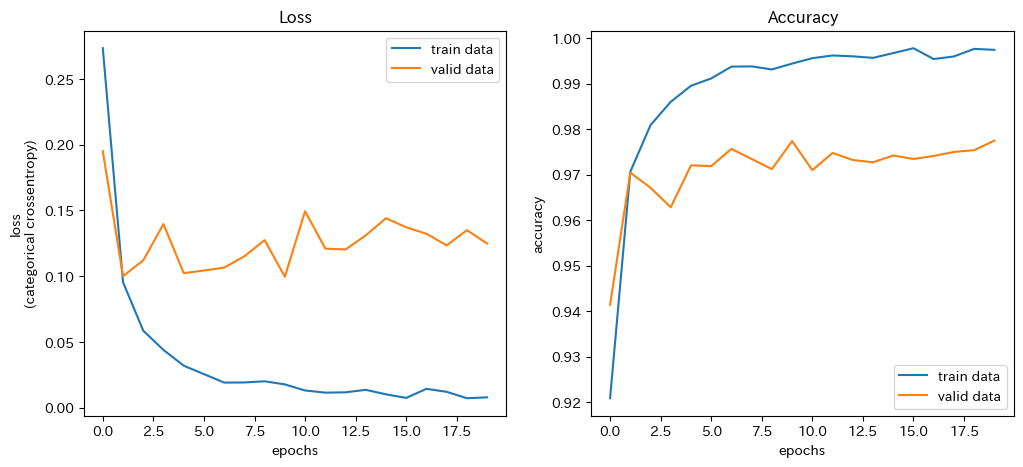

In [ ]:
epochs = log_df["epoch"].values
train_acc = log_df["accuracy"].values
train_loss = log_df["loss"].values
valid_acc = log_df["val_accuracy"].values
valid_loss = log_df["val_loss"].values

fig, axes = plt.subplots(1,2, figsize=(12,5))

axes[0].plot(epochs, train_loss, label="train data")
axes[0].plot(epochs, valid_loss, label="valid data")
axes[0].set_xlabel("epochs")
axes[0].set_ylabel("loss\n(categorical crossentropy)")
axes[0].legend(loc="upper right")
axes[0].set_title("Loss")

axes[1].plot(epochs, train_acc, label="train data")
axes[1].plot(epochs, valid_acc, label="valid data")
axes[1].set_xlabel("epochs")
axes[1].set_ylabel("accuracy")
axes[1].legend(loc="lower right")
axes[1].set_title("Accuracy")

plt.show()

#### 一部の推論結果を可視化する

1/1 [==============================] - 0s 27ms/step


,0,1,2,3,4,5,6,7,8,9
y_test_pred (i=0),2.3274e-17,9.7583e-14,1.2805e-14,8.4538e-14,4.6798e-17,2.5713e-19,1.2621e-21,1.0,6.9456e-17,7.3244e-12


y_test_true (i=0):  7 


y_test_predで最も確率が高いラベル (i=0):  7
x_test（手書き文字画像） (i=0): 


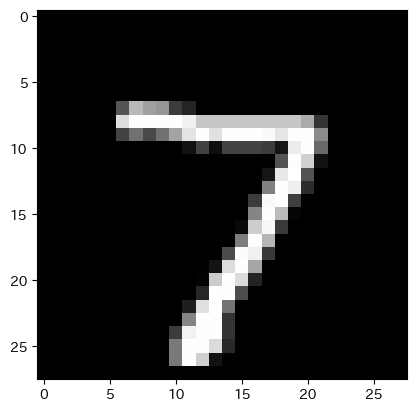


1/1 [==============================] - 0s 24ms/step


,0,1,2,3,4,5,6,7,8,9
y_test_pred (i=1),8.6838e-17,8.2710e-14,1.0,1.6069e-11,1.3233e-21,2.1134e-22,1.2884e-20,3.9030e-14,1.3892e-16,9.4519e-21


y_test_true (i=1):  2 


y_test_predで最も確率が高いラベル (i=1):  2
x_test（手書き文字画像） (i=1): 


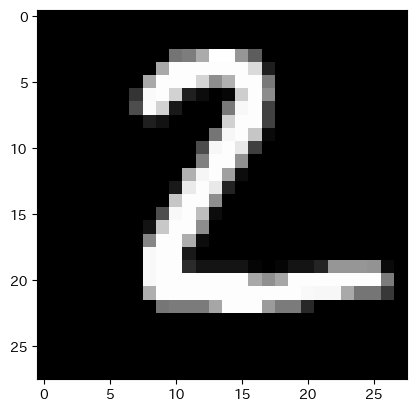


1/1 [==============================] - 0s 30ms/step


,0,1,2,3,4,5,6,7,8,9
y_test_pred (i=2),4.4177e-09,1.0,6.6673e-08,1.9785e-12,8.1210e-08,3.5629e-09,8.0170e-07,9.0999e-07,3.1997e-06,2.7063e-09


y_test_true (i=2):  1 


y_test_predで最も確率が高いラベル (i=2):  1
x_test（手書き文字画像） (i=2): 


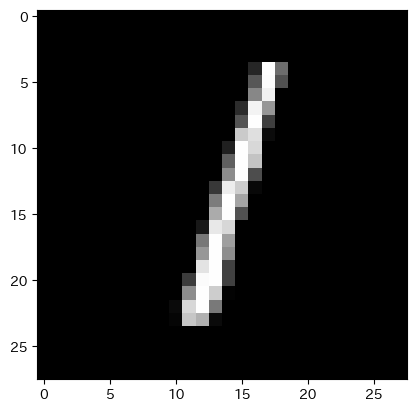

In [ ]:
# テストデータの内，先頭3件のデータを可視化
for i in [0,1,2]:
    y_true = y_test[i]
    y_pred = model.predict(x_test[i].reshape(1,28,28))[0]
    display(pd.DataFrame(columns = range(10), index = [f'y_test_pred (i={str(i)})'], data=[y_pred.tolist()]))

    print("y_test_true", "(i="+str(i)+"): ", y_true, "\n")
    print("\ny_test_predで最も確率が高いラベル", "(i="+str(i)+"): ", tf.math.argmax(y_pred).numpy())

    print("x_test（手書き文字画像）", "(i="+str(i)+"): ")
    plt.imshow(x_test[i], cmap='gray')
    plt.show()
    print()

In [ ]:
# 推論結果と正解ラベルが異なる（間違っている）テストデータの index を出力する
y_pred = np.argmax(model.predict(x_test), axis = -1)
display(np.where( y_pred != y_test) )

313/313 [==============================] - 1s 2ms/step


(array([ 149,  247,  321,  445,  495,  582,  583,  619,  646,  659,  684,
         691,  720,  726,  740,  813,  882,  947,  951, 1014, 1039, 1050,
        1112, 1182, 1224, 1226, 1242, 1247, 1253, 1299, 1319, 1328, 1393,
        1395, 1494, 1527, 1530, 1549, 1569, 1609, 1621, 1670, 1681, 1722,
        1737, 1754, 1790, 1878, 1901, 1911, 1941, 1955, 2004, 2053, 2070,
        2073, 2105, 2109, 2118, 2130, 2135, 2148, 2189, 2272, 2291, 2293,
        2371, 2387, 2395, 2462, 2488, 2582, 2597, 2607, 2648, 2654, 2730,
        2743, 2758, 2771, 2901, 2939, 2953, 2995, 2998, 3073, 3117, 3206,
        3405, 3422, 3451, 3475, 3490, 3503, 3520, 3558, 3597, 3629, 3662,
        3780, 3838, 3893, 3941, 4065, 4123, 4140, 4163, 4176, 4199, 4224,
        4248, 4289, 4294, 4360, 4369, 4497, 4536, 4571, 4615, 4639, 4671,
        4723, 4731, 4761, 4807, 4823, 4876, 4880, 5138, 5331, 5457, 5522,
        5586, 5676, 5734, 5757, 5926, 5936, 5937, 5955, 5973, 6009, 6011,
        6023, 6034, 6045, 6059, 6166, 

1/1 [==============================] - 0s 24ms/step


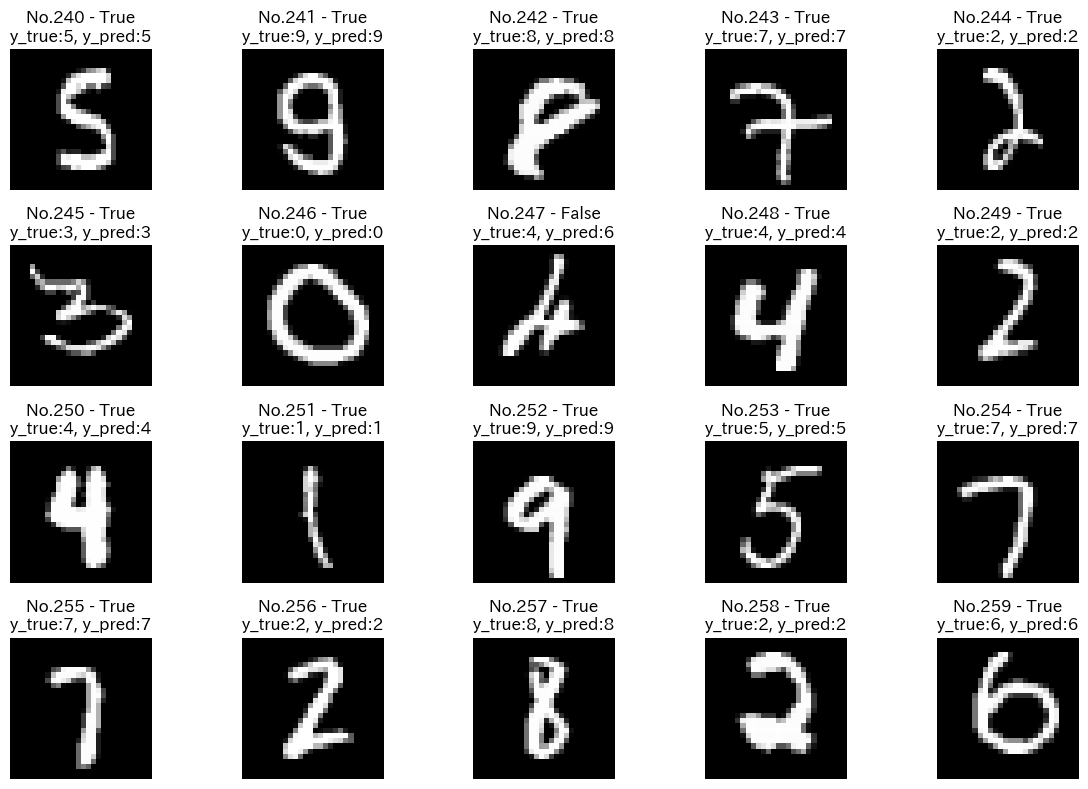

In [ ]:
# テストデータの内，start_indexから20件のデータの推論結果を可視化する

fig = plt.figure(figsize=(12, 8))

ROW = 4
COLUMN = 5
start_index = 240

for i in range(start_index, start_index + ROW * COLUMN):
    y_true = y_test[i]
    y_pred = tf.math.argmax(model.predict(x_test[i].reshape(1,28,28))[0])

    if y_true == y_pred:
        result = "True"
    else:
        result = "False"

    plt.subplot(ROW, COLUMN, (i-start_index) +1 )
    plt.imshow(x_test[i], cmap='gray')
    plt.title("No.{} - {}\ny_true:{}, y_pred:{}".format(i, result, y_true, y_pred))
    plt.axis("off")

fig.tight_layout()
fig.show()

#### 混同行列の描画

結果を混同行列を使って確認してみましょう．混同行列とは以下のような表になっています．

|↓教師データ ／ 出力結果→| 0 | 1 | 2 | 3 | ... |
|:---|:---|:---|:---|:---|:---|
| 0 | 正しく0と判定した|0なのに，1と判定した|0なのに，2と判定した|0なのに，3と判定した|...|
| 1 | 1なのに，0と判定した|正しく1と判定した|1なのに，2と判定した|1なのに，3と判定した|...|
| 2 | 2なのに，0と判定した|2なのに，1と判定した|正しく2と判定した|2なのに，3と判定した|...|
| 3 | 3なのに，0と判定した|3なのに，1と判定した|3なのに，2と判定した|正しく3と判定した|...|
| ... | ... |...|...|...|...|...|


この中では対角線上にある，「正しく0と判定した」「正しく1と判定した」「正しく2と判定した」「正しく3と判定した」に該当すると正答となります．

313/313 [==============================] - 1s 2ms/step


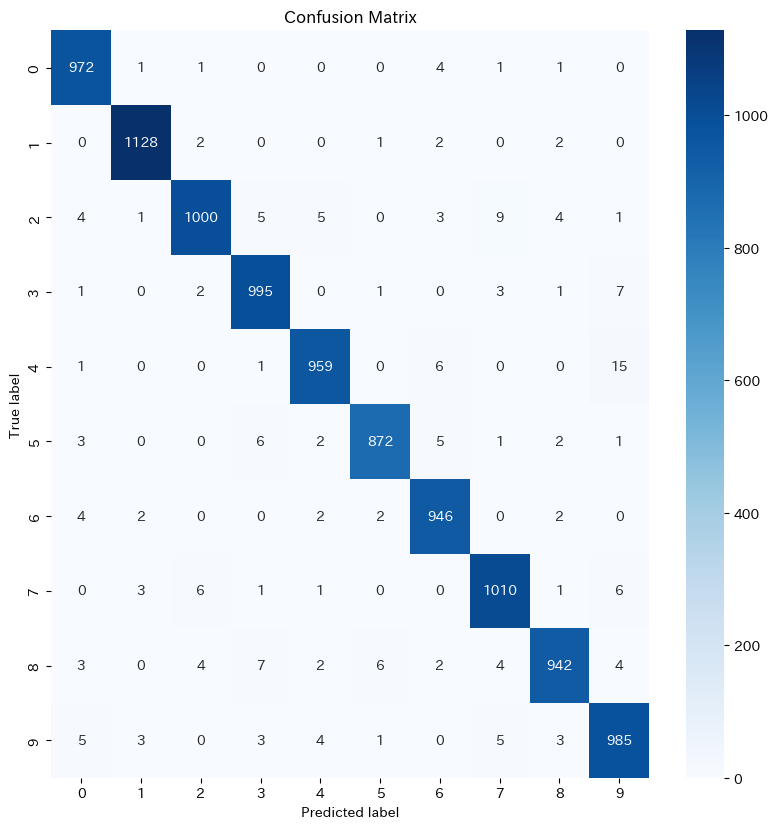

In [ ]:
y_pred = np.argmax(model.predict(x_test), axis = -1)
con_matrix = tf.math.confusion_matrix(labels=y_test, predictions=y_pred).numpy()

con_mat_df = pd.DataFrame(con_matrix,
                     index = list(range(10)),
                     columns = list(range(10))
                     )

figure = plt.figure(figsize=(8, 8))
sns.heatmap(con_mat_df, annot=True, cmap=plt.cm.Blues, fmt='g')
plt.tight_layout()
plt.title('Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

### テストデータの正解割合

In [ ]:
display( pd.Series(y_test, name="テストデータのデータ件数（降順）").value_counts( sort=True ).to_frame().T )

In [ ]:
# テストデータの正解ラベルと，推論結果を比較する（F1-score）
print( classification_report( y_true = y_test, y_pred = y_pred ) )

### 付録：tensorboard による可視化

このコードを実行するときは，Colabを開いているブラウザでサードパーティ製のクッキーを許可してください．（もしブロックしていると，403エラーが表示されます．）

In [ ]:
%tensorboard --logdir logs/fit